<a href="https://colab.research.google.com/github/Ayush264/Hello/blob/main/cybersecurity_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install numpy

In [ ]:
%pip install pandas
%pip install matplotlib
%pip install demoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 1.8 MB/s eta 0:00:00


In [ ]:
%pip install scikit-learn

In [ ]:
%pip install seaborn

In [ ]:
%pip install tweepy
%pip install nbformat
%pip install ipykernel
%pip install nltk
%pip install plotly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.5 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import demoji
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cyberbullying_tweets.csv to cyberbullying_tweets.csv


In [ ]:
import pandas as pd
data = pd.read_csv('cyberbullying_tweets.csv')
data.sample(5)


,tweet_text,cyberbullying_type
45922,@300REZ fuck you dumb nigger get yo uncle ass ...,ethnicity
19725,UHHH SAIL AWAY SWALWELL OKAY WITH OBAMA'S HATR...,religion
9119,Labour drove us into oblivion. Unfortunately t...,gender
12974,Why punish someone for their past? I agree rap...,gender
36617,Morrison really looks like the school bully,age


In [ ]:
print("Five top records of data:")
data.head()

Five top records of data:


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [ ]:
print("Columns/features in data:")
data.columns


Columns/features in data:


Index(['tweet_text', 'cyberbullying_type'], dtype='object')

In [ ]:
#Length of the dataset
print('Length of data is', len(data))

#Shape of data
print("\nShape of data: ", data.shape)

#Rows and columns in the dataset
print('\nCount of rows in the data is:  ', len(data))
print('Count of columns in the data is:  ', len(data.columns))

#Data info
print("\nData info: ", data.info)

#Datatypes of all columns
print("\nDatatypes of columns/features: \n" + str(data.dtypes))
#data.dtypes

Length of data is 47692

Shape of data:  (47692, 2)

Count of rows in the data is:   47692
Count of columns in the data is:   2

Data info:  <bound method DataFrame.info of                                               tweet_text cyberbullying_type
0      In other words #katandandre, your food was cra...  not_cyberbullying
1      Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2      @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3      @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4      @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying
...                                                  ...                ...
47687  Black ppl aren't expected to do anything, depe...          ethnicity
47688  Turner did not withhold his disappointment. Tu...          ethnicity
47689  I swear to God. This dumb nigger bitch. I have...          ethnicity
47690  Yea fuck you RT @therealexel: IF YOURE A NIGGE...          e

In [ ]:
#Checking for Null values
np.sum(data.isnull().any(axis=1))

np.int64(0)

In [ ]:
#Check unique Target Values
print("Unique target values: " + str(data['cyberbullying_type'].unique()))

#Check the number of target values
print("\nNumber of target values: ", data['cyberbullying_type'].nunique())

print("\nCount of each target values: \n" + str(data.cyberbullying_type.value_counts()))

Unique target values: ['not_cyberbullying' 'gender' 'religion' 'other_cyberbullying' 'age'
 'ethnicity']

Number of target values:  6

Count of each target values: 
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


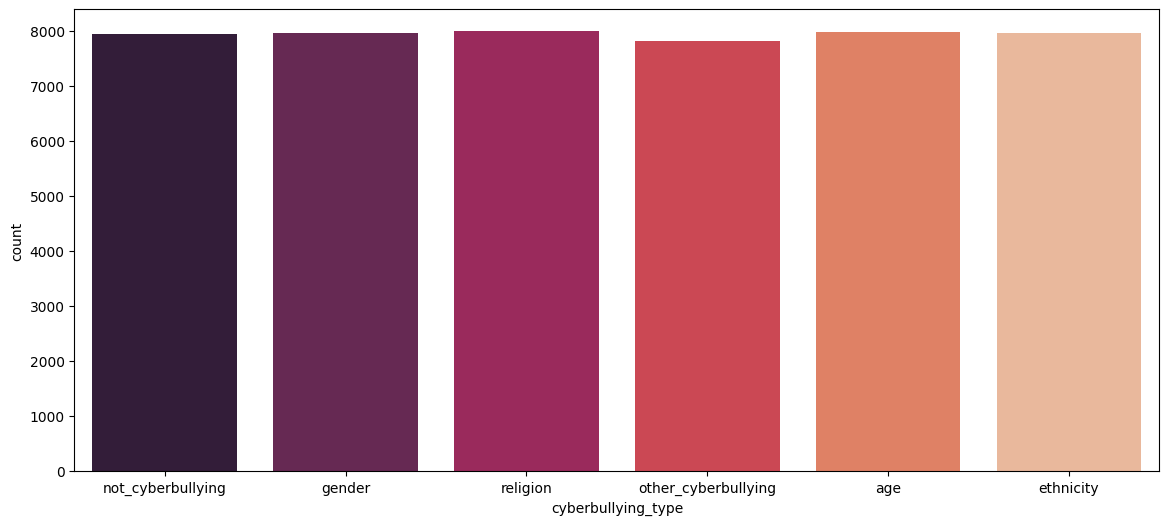

In [ ]:
#Data Visualization of Target Variables

import seaborn as sns
plt.figure(figsize = (14,6))
sns.countplot(x ='cyberbullying_type',data = data, palette = 'rocket')
plt.show()

In [ ]:
import nltk
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')


In [ ]:
import re, string, demoji
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
lemma = WordNetLemmatizer()
STOPWORDS = set(stopwords.words('english'))
STOPWORDS.update(['im','wa','p','t','s','o','e','like'])
def clean_text(text):
    pattern = re.compile(r"(#[A-Za-z0-9]+|@[A-Za-z0-9]+|https?://\S+|www\.\S+|\S+\.[a-z]+|RT @)")
    text = pattern.sub('', text)
    text = " ".join(text.split())
    #text = pattern.sub('', text) # This line seems to be a duplicate and can be removed
    #text = " ".join(text.split()) # This line also seems to be a duplicate and can be removed
    return text # Added return statement to return the cleaned text

In [ ]:
data['tweet_text'] = data.tweet_text.apply(lambda text: clean_text(text))
data.head()

,tweet_text,cyberbullying_type
0,"In other words , your food was crapilicious!",not_cyberbullying
1,Why is so white?,not_cyberbullying
2,a classy whore? Or more red velvet cupcakes?,not_cyberbullying
3,"_Gio meh. :P thanks for the heads up, but not ...",not_cyberbullying
4,This is an ISIS account pretending to be a Kur...,not_cyberbullying


In [ ]:
#Top words for each cyberbullying type!
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'colab'  # Change renderer to 'colab'
for cyber_type in data.cyberbullying_type.unique():
    top50_word = data.tweet_text[data.cyberbullying_type == cyber_type].str.split(expand=True).stack().value_counts()[:50]
    fig = px.bar(top50_word, color=top50_word.values, color_continuous_scale=px.colors.sequential.RdPu, custom_data=[top50_word.values])
    fig.update_traces(hovertemplate='<b>Count: </b>%{customdata[0]}')
    fig.update_layout(title=f"Top 50 words for {cyber_type}",
    template='simple_white',
    hovermode='x unified')
    fig.show()

In [ ]:
ENCODE_DICT = {'not_cyberbullying': 0,
             'gender': 1,
             'religion': 2,
             'other_cyberbullying': 3,
             'age': 4,
             'ethnicity': 5}
data['cyberbullying_type'] = data.cyberbullying_type.replace(ENCODE_DICT)
print(data.cyberbullying_type.unique())
data.sample(10)

[0 1 2 3 4 5]


,tweet_text,cyberbullying_type
27728,I keep hearing that GamerGate is opposed to ha...,3
28255,Are you retarded or something?,3
19946,Although Salafi Jihadist terrorism has been pe...,2
1039,"@__enimey__ Nope, reported by multiple sources.",0
30867,slept then too,3
28620,. no idea. it's not going to work very well. t...,3
19349,"I fucking hate muslims sometimes. Like, this i...",2
44985,word you're dumb as fuck lmfao . Calling someo...,5
3609,just grabbed my cheeks.,0
1841,Not even the roaches &amp; rodents would eat K...,0


In [ ]:
#Verification

data.tweet_text[data.cyberbullying_type == 1].sample(10)

,tweet_text
8897,So the game portraying it's only openly gay ch...
11554,"dudes: ""I don't think women want what men have"""
13552,i have been bullied for as long as i can remem...
12502,4 Reasons Why About via both genders r guilty ...
12531,"I just got so mad, I’m tryna be a better femal..."
9824,gays will go after a comedian for making rape ...
10836,How about you unfollow me while you are at it....
13496,Rape isn't funny but I bet you laugh at an AID...
11124,"Miley Cyrus Rides Blow-Up Dick, Tells Rape Jok..."
9564,Congressman McCarthy is it the GOP standard to...


In [ ]:
#Count Vectorizer

#Create word vector(count)
CountVector = CountVectorizer(max_features = 2000)

X = CountVector.fit_transform(data.tweet_text).toarray()
y = data.cyberbullying_type.values

print(X.shape, y.shape)

(47692, 2000) (47692,)


In [ ]:
#Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=555)

print(f"Shape of X train data: {X_train.shape} and it's label's shape: {y_train.shape}")
print(f"Shape of X test data: {X_test.shape} and it's label's shape {y_test.shape}")

Shape of X train data: (38153, 2000) and it's label's shape: (38153,)
Shape of X test data: (9539, 2000) and it's label's shape (9539,)


In [ ]:
#Prediction using Random Forest Classifier

rf = RandomForestClassifier(random_state=555)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print('Accuracy of Random Forest Classifier: %f' %(accuracy_score(y_pred, y_test)))
score_rft = round(accuracy_score(y_pred,y_test)*100,2)

Accuracy of Random Forest Classifier: 0.797463


In [ ]:
#Prediction using Naive Bayes

from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

y_prednb = mnb.predict(X_test)
print('Accuracy of Multinomial Naive Bayes: %f' %(accuracy_score(y_prednb, y_test)))
score_mnbt = round(accuracy_score(y_prednb,y_test)*100,2)

Accuracy of Multinomial Naive Bayes: 0.749974


In [ ]:
#Prediction using Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(max_depth=25)
tree_clf.fit(X_train, y_train)

y_preddt = tree_clf.predict(X_test)
print('Accuracy of Decision Tree Classifier: %f' %(accuracy_score(y_preddt, y_test)))
score_dtt = round(accuracy_score(y_preddt,y_test)*100,2)

Accuracy of Decision Tree Classifier: 0.774085


In [ ]:
#Prediction using Logistic Regression

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(solver='lbfgs')
clf.fit(X_train, y_train)

y_predlr = clf.predict(X_test)
print('Accuracy of Logistic Regression: %f' %(accuracy_score(y_predlr, y_test)))
score_lrt = round(accuracy_score(y_predlr,y_test)*100,2)

Accuracy of Logistic Regression: 0.809414


In [ ]:
#Prediction using Linear SVM

from sklearn.svm import LinearSVC
SVCmodel = LinearSVC()
SVCmodel.fit(X_train, y_train)

y_predsv = SVCmodel.predict(X_test)
print('Accuracy of Linear SVM: %f' %(accuracy_score(y_predsv, y_test)))
score_svt = round(accuracy_score(y_predsv,y_test)*100,2)

Accuracy of Linear SVM: 0.805640


In [ ]:
#Summary

scores = [abs(score_rft), abs(score_mnbt), abs(score_dtt), abs(score_lrt), abs(score_svt)]
algorithms = ["randomforest tree","naivebayes","decisiontree", "logistic regression", "linear svm"]

for i in range(len(algorithms)):
    print("The accuracy score achieved using "+algorithms[i]+" is: "+str(scores[i])+" %")

The accuracy score achieved using randomforest tree is: 79.75 %
The accuracy score achieved using naivebayes is: 75.0 %
The accuracy score achieved using decisiontree is: 77.41 %
The accuracy score achieved using logistic regression is: 80.94 %
The accuracy score achieved using linear svm is: 80.56 %


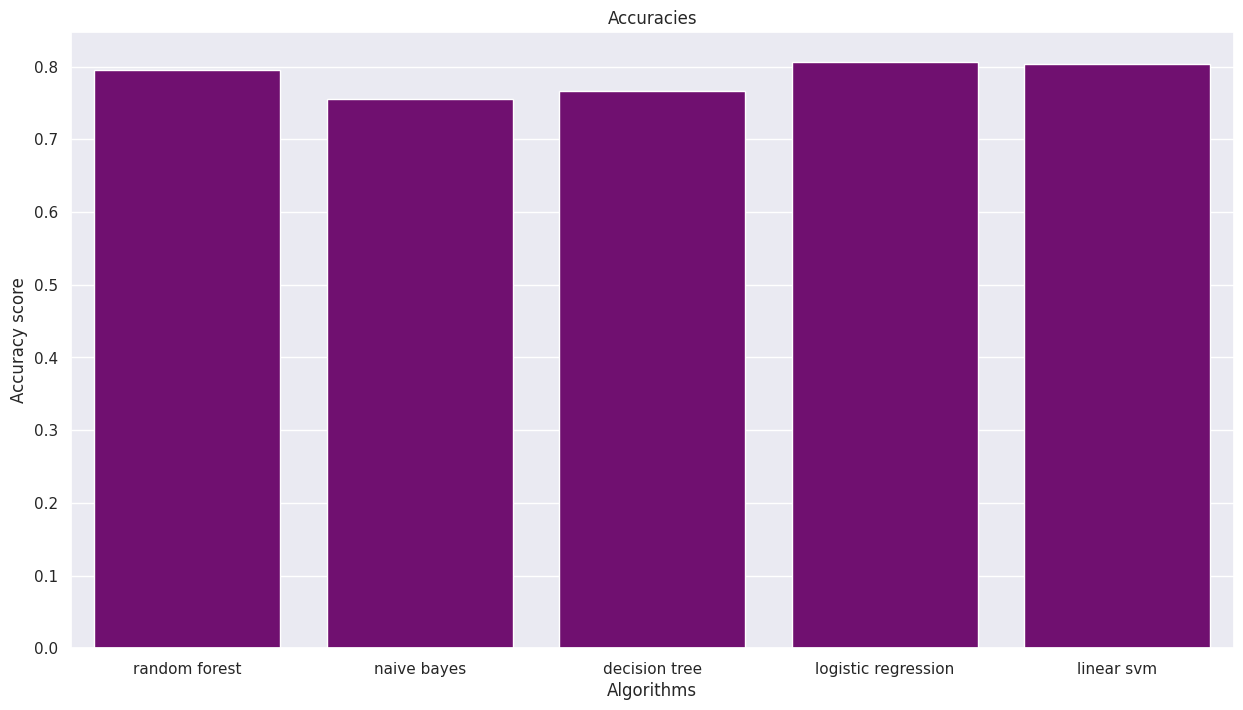

In [ ]:
#Visualization of Accuracies

import seaborn as sns
import matplotlib.pyplot as plt

# Example data
algorithms = ['random forest', 'naive bayes', 'decision tree', 'logistic regression', 'linear svm']
scores = [0.796, 0.756, 0.766, 0.807, 0.804]

# Set figure size
sns.set(rc={'figure.figsize':(15,8)})

# Create the plot
plt.title("Accuracies")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score")

# Plot the barplot
sns.barplot(x=algorithms, y=scores, color = 'purple')

# Display the plot
plt.show()

In [ ]:
import pickle
filename = 'cyber.pkl'
pickle.dump(clf, open(filename, 'wb'))

#load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))
result = loaded_model.score(X_test, y_test)
print(result)

0.8094139846944124


In [ ]:
#Testing

def preprocess(data):
    #preprocess
    a = re.sub('[^a-zA-Z]',' ',data)
    a = a.lower()
    a = a.split()
    a = [lemma.lemmatize(word) for word in a ]
    a = ' '.join(a)
    return a

In [ ]:
import pickle
filename = 'tfidf.pkl'
pickle.dump(clf, open(filename, 'wb'))

In [ ]:
import tweepy
import pandas as pd
import csv
from tkinter import *
from tkinter import messagebox
from tkinter.filedialog import askopenfilename
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import ImageTk,Image
import seaborn as sns

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pickle

data = pd.read_csv("cyberbullying_tweets.csv")

tweets = data['tweet_text']
labels = data['cyberbullying_type']

# TF-IDF vectorizer and transform the tweets into TF-IDF features
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(tweets)

clf = LogisticRegression(max_iter=1000)
clf.fit(X, labels)

with open('model.pkl', 'wb') as model_file:
    pickle.dump(clf, model_file)

    with open('tfidf.pkl', 'wb') as tfidf_file:
        pickle.dump(tfidf, tfidf_file)

        print("Model and TF-IDF vectorizer have been saved successfully!")


Model and TF-IDF vectorizer have been saved successfully!


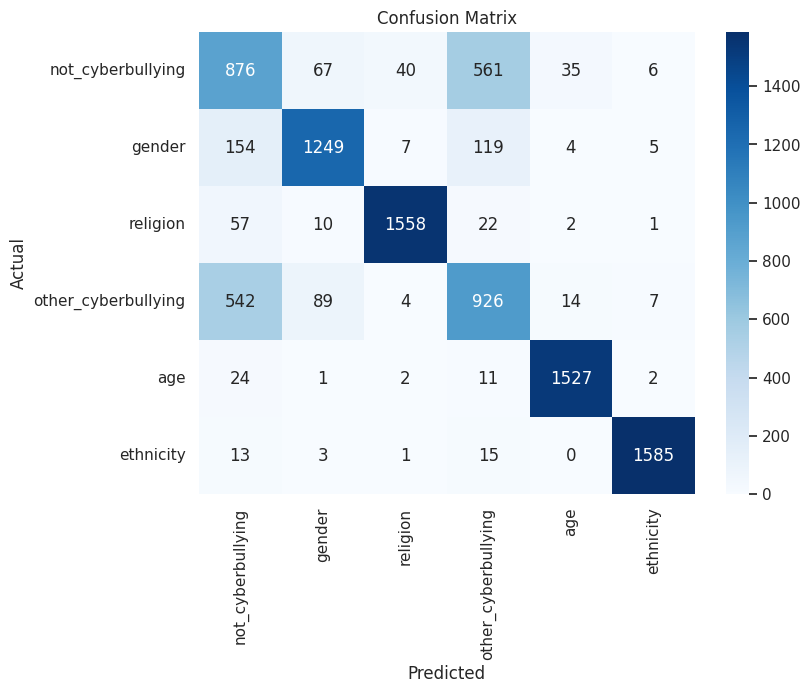


Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying       0.53      0.55      0.54      1585
             gender       0.88      0.81      0.84      1538
           religion       0.97      0.94      0.96      1650
other_cyberbullying       0.56      0.59      0.57      1582
                age       0.97      0.97      0.97      1567
          ethnicity       0.99      0.98      0.98      1617

           accuracy                           0.81      9539
          macro avg       0.81      0.81      0.81      9539
       weighted avg       0.82      0.81      0.81      9539



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_test and y_predlr are available from previous cells
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_predlr)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ENCODE_DICT.keys(), yticklabels=ENCODE_DICT.keys()) # Assuming ENCODE_DICT is available
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_predlr, target_names=ENCODE_DICT.keys())) # Assuming ENCODE_DICT is available

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the trained model and TF-IDF vectorizer
try:
    with open('model.pkl', 'rb') as model_file:
        clf = pickle.load(model_file)
    with open('tfidf.pkl', 'rb') as tfidf_file:
        tfidf = pickle.load(tfidf_file)
except FileNotFoundError:
    print("Model or TF-IDF files not found. Please train and save the model first.")

# Assuming preprocess function is defined in a previous cell
# If not, you may need to include it here or ensure it's executed before this cell

def predict_cyberbullying(tweet_text):
    # Preprocess the input tweet (assuming preprocess function is available)
    processed_tweet = preprocess(tweet_text) # Make sure preprocess is defined and accessible

    # Vectorize the preprocessed tweet
    vect = tfidf.transform([processed_tweet])

    # Make a prediction
    prediction = clf.predict(vect)

    # Map prediction to label
    # Assuming ENCODE_DICT is available from a previous cell
    # If not, you may need to include it here or ensure it's executed before this cell
    reverse_encode_dict = {v: k for k, v in ENCODE_DICT.items()} # Make sure ENCODE_DICT is defined and accessible
    predicted_label = reverse_encode_dict.get(prediction[0], "Unknown")

    return predicted_label

# Create interactive widgets
tweet_input = widgets.Textarea(
    value='',
    placeholder='Enter tweet text here',
    description='Tweet:',
    disabled=False,
    layout=widgets.Layout(width='500px', height='100px')
)

predict_button = widgets.Button(
    description='Predict',
    disabled=False,
    button_style='success',
    tooltip='Click to predict cyberbullying type'
)

output_label = widgets.Label(
    value='',
    description='Prediction:',
    layout=widgets.Layout(width='auto')
)

def on_button_click(b):
    tweet = tweet_input.value
    if tweet:
        prediction = predict_cyberbullying(tweet)
        output_label.value = prediction
    else:
        output_label.value = "Please enter some text."

predict_button.on_click(on_button_click)

# Display the widgets
display(tweet_input, predict_button, output_label)

Textarea(value='', description='Tweet:', layout=Layout(height='100px', width='500px'), placeholder='Enter twee…

Button(button_style='success', description='Predict', style=ButtonStyle(), tooltip='Click to predict cyberbull…

Label(value='', description='Prediction:', layout=Layout(width='auto'))

In [ ]:
# Display a few sample tweets from the original data
print("Sample tweets from the dataset:")
display(data.sample(5))

Sample tweets from the dataset:


,tweet_text,cyberbullying_type
6772,Just watched @chicken_film woahhhhh break my f...,not_cyberbullying
6526,#FateNumberFor,not_cyberbullying
38419,when i was at high school in 2005 all the quee...,age
43941,@dmelliottjr fuck you dumb nigger. Hows that. ...,ethnicity
9143,"RT @KhalilAOfficial First, female sports. Now ...",gender
